In [3]:
# ============================================================
# Imports
# ============================================================
import os
import csv
import time
import random
import warnings

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR, _LRScheduler
from torch.cuda.amp import autocast, GradScaler

from PIL import Image, ImageEnhance, ImageOps
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] device = {device}, gpu count = {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")


[INFO] device = cuda, gpu count = 2
[INFO] GPU: Tesla T4


In [4]:
# ============================================================
# Config  
# Default matches the README's best-CIFAR-10 command:
#   python main.py --dataset c10 --label-smoothing --autoaugment
# ============================================================
QUICK_TEST = False  # set True first to sanity-check the whole pipeline in a few minutes

class Args:
    # data / model
    dataset        = "c10"        # "c10", "c100", "svhn"
    model_name     = "vit"
    patch          = 8
    batch_size     = 128
    eval_batch_size = 1024
    dropout        = 0.0
    head           = 12
    num_layers     = 7
    hidden         = 384
    mlp_hidden     = 384
    off_cls_token  = False        # True -> use mean pooling instead of CLS token

    # optimization
    lr             = 1e-3
    min_lr         = 1e-5
    beta1          = 0.9
    beta2          = 0.999
    weight_decay   = 5e-5
    warmup_epoch   = 5
    max_epochs     = 120
    precision      = 16           # 16 -> mixed precision (if CUDA available)

    # loss
    criterion      = "ce"
    label_smoothing = True
    smoothing      = 0.1

    # augmentation
    autoaugment    = True
    rcpaste        = False
    cutmix         = False
    mixup          = False

    # misc
    off_benchmark  = False
    dry_run        = False
    seed           = 42
    api_key        = None         # comet.ml disabled -> CSV logging is used instead
    project_name   = "VisionTransformer"

args = Args()

if QUICK_TEST:
    args.max_epochs = 3
    args.warmup_epoch = 1
    print("[INFO] QUICK_TEST=True -> max_epochs reduced to 3 for a fast pipeline check.")

# derived fields (same logic as main.py)
args.benchmark = not args.off_benchmark
args.gpus = torch.cuda.device_count()
_cpu_count = os.cpu_count() or 4
args.num_workers = min(4 * args.gpus, _cpu_count) if args.gpus else min(8, _cpu_count)
args.is_cls_token = not args.off_cls_token
if not args.gpus:
    args.precision = 32

if args.mlp_hidden != args.hidden * 4:
    print(f"[INFO] In the original paper, mlp_hidden(CURRENT:{args.mlp_hidden}) is usually hidden*4={args.hidden*4}. "
          f"This repo intentionally deviates from that (default mlp_hidden=384).")

torch.manual_seed(args.seed)
np.random.seed(args.seed)
random.seed(args.seed)
torch.backends.cudnn.benchmark = args.benchmark

RESUME = True  # if True, auto-resumes from a saved "last" checkpoint when present
LOG_DIR = "/kaggle/working/logs"
CKPT_DIR = "/kaggle/working/weights"
DATA_ROOT = "/kaggle/working/data"
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


[INFO] In the original paper, mlp_hidden(CURRENT:384) is usually hidden*4=1536. This repo intentionally deviates from that (default mlp_hidden=384).


In [5]:
# ============================================================
# ops.py  (AutoAugment primitive ops)
# Fix applied: np.int -> int (np.int was removed in numpy>=1.24)
# ============================================================
class ShearX(object):
    def __init__(self, fillcolor=(128, 128, 128)):
        self.fillcolor = fillcolor

    def __call__(self, x, magnitude):
        return x.transform(
            x.size, Image.AFFINE, (1, magnitude * random.choice([-1, 1]), 0, 0, 1, 0),
            Image.BICUBIC, fillcolor=self.fillcolor)


class ShearY(object):
    def __init__(self, fillcolor=(128, 128, 128)):
        self.fillcolor = fillcolor

    def __call__(self, x, magnitude):
        return x.transform(
            x.size, Image.AFFINE, (1, 0, 0, magnitude * random.choice([-1, 1]), 1, 0),
            Image.BICUBIC, fillcolor=self.fillcolor)


class TranslateX(object):
    def __init__(self, fillcolor=(128, 128, 128)):
        self.fillcolor = fillcolor

    def __call__(self, x, magnitude):
        return x.transform(
            x.size, Image.AFFINE, (1, 0, magnitude * x.size[0] * random.choice([-1, 1]), 0, 1, 0),
            fillcolor=self.fillcolor)


class TranslateY(object):
    def __init__(self, fillcolor=(128, 128, 128)):
        self.fillcolor = fillcolor

    def __call__(self, x, magnitude):
        return x.transform(
            x.size, Image.AFFINE, (1, 0, 0, 0, 1, magnitude * x.size[1] * random.choice([-1, 1])),
            fillcolor=self.fillcolor)


class Rotate(object):
    def __call__(self, x, magnitude):
        rot = x.convert("RGBA").rotate(magnitude)
        return Image.composite(rot, Image.new("RGBA", rot.size, (128,) * 4), rot).convert(x.mode)


class Color(object):
    def __call__(self, x, magnitude):
        return ImageEnhance.Color(x).enhance(1 + magnitude * random.choice([-1, 1]))


class Posterize(object):
    def __call__(self, x, magnitude):
        return ImageOps.posterize(x, magnitude)


class Solarize(object):
    def __call__(self, x, magnitude):
        return ImageOps.solarize(x, magnitude)


class Contrast(object):
    def __call__(self, x, magnitude):
        return ImageEnhance.Contrast(x).enhance(1 + magnitude * random.choice([-1, 1]))


class Sharpness(object):
    def __call__(self, x, magnitude):
        return ImageEnhance.Sharpness(x).enhance(1 + magnitude * random.choice([-1, 1]))


class Brightness(object):
    def __call__(self, x, magnitude):
        return ImageEnhance.Brightness(x).enhance(1 + magnitude * random.choice([-1, 1]))


class AutoContrast(object):
    def __call__(self, x, magnitude):
        return ImageOps.autocontrast(x)


class Equalize(object):
    def __call__(self, x, magnitude):
        return ImageOps.equalize(x)


class Invert(object):
    def __call__(self, x, magnitude):
        return ImageOps.invert(x)


In [6]:
# ============================================================
# autoaugment.py  (CIFAR10Policy is what we use; kept ImageNet/SVHN too)
# ============================================================
class SubPolicy(object):
    def __init__(self, p1, operation1, magnitude_idx1, p2, operation2, magnitude_idx2, fillcolor=(128, 128, 128)):
        ranges = {
            "shearX": np.linspace(0, 0.3, 10),
            "shearY": np.linspace(0, 0.3, 10),
            "translateX": np.linspace(0, 150 / 331, 10),
            "translateY": np.linspace(0, 150 / 331, 10),
            "rotate": np.linspace(0, 30, 10),
            "color": np.linspace(0.0, 0.9, 10),
            "posterize": np.round(np.linspace(8, 4, 10), 0).astype(int),   # fixed: np.int -> int
            "solarize": np.linspace(256, 0, 10),
            "contrast": np.linspace(0.0, 0.9, 10),
            "sharpness": np.linspace(0.0, 0.9, 10),
            "brightness": np.linspace(0.0, 0.9, 10),
            "autocontrast": [0] * 10,
            "equalize": [0] * 10,
            "invert": [0] * 10
        }

        func = {
            "shearX": ShearX(fillcolor=fillcolor),
            "shearY": ShearY(fillcolor=fillcolor),
            "translateX": TranslateX(fillcolor=fillcolor),
            "translateY": TranslateY(fillcolor=fillcolor),
            "rotate": Rotate(),
            "color": Color(),
            "posterize": Posterize(),
            "solarize": Solarize(),
            "contrast": Contrast(),
            "sharpness": Sharpness(),
            "brightness": Brightness(),
            "autocontrast": AutoContrast(),
            "equalize": Equalize(),
            "invert": Invert()
        }

        self.p1 = p1
        self.operation1 = func[operation1]
        self.magnitude1 = ranges[operation1][magnitude_idx1]
        self.p2 = p2
        self.operation2 = func[operation2]
        self.magnitude2 = ranges[operation2][magnitude_idx2]

    def __call__(self, img):
        if random.random() < self.p1:
            img = self.operation1(img, self.magnitude1)
        if random.random() < self.p2:
            img = self.operation2(img, self.magnitude2)
        return img


class CIFAR10Policy(object):
    """Randomly choose one of the best 25 Sub-policies on CIFAR10."""
    def __init__(self, fillcolor=(128, 128, 128)):
        self.policies = [
            SubPolicy(0.1, "invert", 7, 0.2, "contrast", 6, fillcolor),
            SubPolicy(0.7, "rotate", 2, 0.3, "translateX", 9, fillcolor),
            SubPolicy(0.8, "sharpness", 1, 0.9, "sharpness", 3, fillcolor),
            SubPolicy(0.5, "shearY", 8, 0.7, "translateY", 9, fillcolor),
            SubPolicy(0.5, "autocontrast", 8, 0.9, "equalize", 2, fillcolor),

            SubPolicy(0.2, "shearY", 7, 0.3, "posterize", 7, fillcolor),
            SubPolicy(0.4, "color", 3, 0.6, "brightness", 7, fillcolor),
            SubPolicy(0.3, "sharpness", 9, 0.7, "brightness", 9, fillcolor),
            SubPolicy(0.6, "equalize", 5, 0.5, "equalize", 1, fillcolor),
            SubPolicy(0.6, "contrast", 7, 0.6, "sharpness", 5, fillcolor),

            SubPolicy(0.7, "color", 7, 0.5, "translateX", 8, fillcolor),
            SubPolicy(0.3, "equalize", 7, 0.4, "autocontrast", 8, fillcolor),
            SubPolicy(0.4, "translateY", 3, 0.2, "sharpness", 6, fillcolor),
            SubPolicy(0.9, "brightness", 6, 0.2, "color", 8, fillcolor),
            SubPolicy(0.5, "solarize", 2, 0.0, "invert", 3, fillcolor),

            SubPolicy(0.2, "equalize", 0, 0.6, "autocontrast", 0, fillcolor),
            SubPolicy(0.2, "equalize", 8, 0.6, "equalize", 4, fillcolor),
            SubPolicy(0.9, "color", 9, 0.6, "equalize", 6, fillcolor),
            SubPolicy(0.8, "autocontrast", 4, 0.2, "solarize", 8, fillcolor),
            SubPolicy(0.1, "brightness", 3, 0.7, "color", 0, fillcolor),

            SubPolicy(0.4, "solarize", 5, 0.9, "autocontrast", 3, fillcolor),
            SubPolicy(0.9, "translateY", 9, 0.7, "translateY", 9, fillcolor),
            SubPolicy(0.9, "autocontrast", 2, 0.8, "solarize", 3, fillcolor),
            SubPolicy(0.8, "equalize", 8, 0.1, "invert", 3, fillcolor),
            SubPolicy(0.7, "translateY", 9, 0.9, "autocontrast", 1, fillcolor)
        ]

    def __call__(self, img):
        policy_idx = random.randint(0, len(self.policies) - 1)
        return self.policies[policy_idx](img)

    def __repr__(self):
        return "AutoAugment CIFAR10 Policy"


In [7]:
# ============================================================
# da.py  (RandomCropPaste, CutMix, MixUp)
# Fix applied: np.int -> int in RandomCropPaste._rand_bbox
# ============================================================
class RandomCropPaste(object):
    def __init__(self, size, alpha=1.0, flip_p=0.5):
        """Randomly flip and paste a cropped image on the same image."""
        self.size = size
        self.alpha = alpha
        self.flip_p = flip_p

    def __call__(self, img):
        lam = np.random.beta(self.alpha, self.alpha)
        front_bbx1, front_bby1, front_bbx2, front_bby2 = self._rand_bbox(lam)
        img_front = img[:, front_bby1:front_bby2, front_bbx1:front_bbx2].clone()
        front_w = front_bbx2 - front_bbx1
        front_h = front_bby2 - front_bby1

        img_x1 = np.random.randint(0, high=max(self.size - front_w, 1))
        img_y1 = np.random.randint(0, high=max(self.size - front_h, 1))
        img_x2 = img_x1 + front_w
        img_y2 = img_y1 + front_h

        if np.random.rand(1) <= self.flip_p:
            img_front = img_front.flip((-1,))
        if np.random.rand(1) <= self.flip_p:
            img = img.flip((-1,))

        mixup_alpha = np.random.rand(1)
        img[:, img_y1:img_y2, img_x1:img_x2] *= mixup_alpha
        img[:, img_y1:img_y2, img_x1:img_x2] += img_front * (1 - mixup_alpha)
        return img

    def _rand_bbox(self, lam):
        W = self.size
        H = self.size
        cut_rat = np.sqrt(1. - lam)
        cut_w = int(W * cut_rat)     # fixed: np.int -> int
        cut_h = int(H * cut_rat)     # fixed: np.int -> int

        cx = np.random.randint(W)
        cy = np.random.randint(H)

        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)

        return bbx1, bby1, bbx2, bby2


class CutMix(object):
    def __init__(self, size, beta):
        self.size = size
        self.beta = beta

    def __call__(self, batch):
        img, label = batch
        rand_img, rand_label = self._shuffle_minibatch(batch)
        lambda_ = np.random.beta(self.beta, self.beta)
        r_x = np.random.uniform(0, self.size)
        r_y = np.random.uniform(0, self.size)
        r_w = self.size * np.sqrt(1 - lambda_)
        r_h = self.size * np.sqrt(1 - lambda_)
        x1 = int(np.clip(r_x - r_w // 2, a_min=0, a_max=self.size))
        x2 = int(np.clip(r_x + r_w // 2, a_min=0, a_max=self.size))
        y1 = int(np.clip(r_y - r_h // 2, a_min=0, a_max=self.size))
        y2 = int(np.clip(r_y + r_h // 2, a_min=0, a_max=self.size))
        img[:, :, x1:x2, y1:y2] = rand_img[:, :, x1:x2, y1:y2]

        lambda_ = 1 - (x2 - x1) * (y2 - y1) / (self.size * self.size)
        return img, label, rand_label, lambda_

    def _shuffle_minibatch(self, batch):
        img, label = batch
        rand_img, rand_label = img.clone(), label.clone()
        rand_idx = torch.randperm(img.size(0))
        rand_img, rand_label = rand_img[rand_idx], rand_label[rand_idx]
        return rand_img, rand_label


# Code: https://github.com/facebookresearch/mixup-cifar10
class MixUp(object):
    def __init__(self, alpha=0.1):
        self.alpha = alpha

    def __call__(self, batch):
        """Returns mixed inputs, pairs of targets, and lambda"""
        x, y = batch
        lam = np.random.beta(self.alpha, self.alpha)
        batch_size = x.size(0)
        index = torch.randperm(batch_size)
        mixed_x = lam * x + (1 - lam) * x[index, :]
        y_a, y_b = y, y[index]
        return mixed_x, y_a, y_b, lam


In [8]:
# ============================================================
# criterions.py
# ============================================================
class LabelSmoothingCrossEntropyLoss(nn.Module):
    def __init__(self, classes, smoothing=0.0, dim=-1):
        super(LabelSmoothingCrossEntropyLoss, self).__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.dim = dim

    def forward(self, pred, target):
        pred = pred.log_softmax(dim=self.dim)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (self.cls - 1))
            true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * pred, dim=self.dim))


In [9]:
# ============================================================
# layers.py  (Transformer encoder + multi-head self-attention)
# ============================================================
class TransformerEncoder(nn.Module):
    def __init__(self, feats: int, mlp_hidden: int, head: int = 8, dropout: float = 0.):
        super(TransformerEncoder, self).__init__()
        self.la1 = nn.LayerNorm(feats)
        self.msa = MultiHeadSelfAttention(feats, head=head, dropout=dropout)
        self.la2 = nn.LayerNorm(feats)
        self.mlp = nn.Sequential(
            nn.Linear(feats, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, feats),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        out = self.msa(self.la1(x)) + x
        out = self.mlp(self.la2(out)) + out
        return out


class MultiHeadSelfAttention(nn.Module):
    def __init__(self, feats: int, head: int = 8, dropout: float = 0.):
        super(MultiHeadSelfAttention, self).__init__()
        self.head = head
        self.feats = feats
        self.sqrt_d = self.feats ** 0.5

        self.q = nn.Linear(feats, feats)
        self.k = nn.Linear(feats, feats)
        self.v = nn.Linear(feats, feats)

        self.o = nn.Linear(feats, feats)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        b, n, f = x.size()
        q = self.q(x).view(b, n, self.head, self.feats // self.head).transpose(1, 2)
        k = self.k(x).view(b, n, self.head, self.feats // self.head).transpose(1, 2)
        v = self.v(x).view(b, n, self.head, self.feats // self.head).transpose(1, 2)

        score = F.softmax(torch.einsum("bhif, bhjf->bhij", q, k) / self.sqrt_d, dim=-1)  # (b,h,n,n)
        attn = torch.einsum("bhij, bhjf->bihf", score, v)  # (b,n,h,f//h)
        o = self.dropout(self.o(attn.flatten(2)))
        return o


In [10]:
# ============================================================
# vit.py  (the ViT model itself)
# ============================================================
class ViT(nn.Module):
    def __init__(self, in_c: int = 3, num_classes: int = 10, img_size: int = 32, patch: int = 8,
                 dropout: float = 0., num_layers: int = 7, hidden: int = 384, mlp_hidden: int = 384 * 4,
                 head: int = 8, is_cls_token: bool = True):
        super(ViT, self).__init__()

        self.patch = patch  # number of patches in one row (or col)
        self.is_cls_token = is_cls_token
        self.patch_size = img_size // self.patch
        f = (img_size // self.patch) ** 2 * 3  # patch vec length
        num_tokens = (self.patch ** 2) + 1 if self.is_cls_token else (self.patch ** 2)

        self.emb = nn.Linear(f, hidden)  # (b, n, f)
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden)) if is_cls_token else None
        self.pos_emb = nn.Parameter(torch.randn(1, num_tokens, hidden))
        enc_list = [TransformerEncoder(hidden, mlp_hidden=mlp_hidden, dropout=dropout, head=head) for _ in range(num_layers)]
        self.enc = nn.Sequential(*enc_list)
        self.fc = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, x):
        out = self._to_words(x)
        out = self.emb(out)
        if self.is_cls_token:
            out = torch.cat([self.cls_token.repeat(out.size(0), 1, 1), out], dim=1)
        out = out + self.pos_emb
        out = self.enc(out)
        if self.is_cls_token:
            out = out[:, 0]
        else:
            out = out.mean(1)
        out = self.fc(out)
        return out

    def _to_words(self, x):
        """(b, c, h, w) -> (b, n, f)"""
        out = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size).permute(0, 2, 3, 4, 5, 1)
        out = out.reshape(x.size(0), self.patch ** 2, -1)
        return out


In [11]:
# ============================================================
# utils.py  (get_transform / get_dataset / get_model / get_criterion / get_experiment_name)
# ============================================================
def get_criterion(args):
    if args.criterion == "ce":
        if args.label_smoothing:
            criterion = LabelSmoothingCrossEntropyLoss(args.num_classes, smoothing=args.smoothing)
        else:
            criterion = nn.CrossEntropyLoss()
    else:
        raise ValueError(f"{args.criterion}?")
    return criterion


def get_model(args):
    if args.model_name == "vit":
        net = ViT(
            args.in_c,
            args.num_classes,
            img_size=args.size,
            patch=args.patch,
            dropout=args.dropout,
            mlp_hidden=args.mlp_hidden,
            num_layers=args.num_layers,
            hidden=args.hidden,
            head=args.head,
            is_cls_token=args.is_cls_token
        )
    else:
        raise NotImplementedError(f"{args.model_name} is not implemented yet...")
    return net


def get_transform(args):
    train_transform = []
    test_transform = []
    train_transform += [transforms.RandomCrop(size=args.size, padding=args.padding)]
    if args.dataset != "svhn":
        train_transform += [transforms.RandomHorizontalFlip()]

    if args.autoaugment:
        if args.dataset in ("c10", "c100"):
            train_transform.append(CIFAR10Policy())
        else:
            print(f"No AutoAugment for {args.dataset}")

    train_transform += [
        transforms.ToTensor(),
        transforms.Normalize(mean=args.mean, std=args.std)
    ]
    if args.rcpaste:
        train_transform += [RandomCropPaste(size=args.size)]

    test_transform += [
        transforms.ToTensor(),
        transforms.Normalize(mean=args.mean, std=args.std)
    ]

    train_transform = transforms.Compose(train_transform)
    test_transform = transforms.Compose(test_transform)
    return train_transform, test_transform


def get_dataset(args):
    root = DATA_ROOT
    if args.dataset == "c10":
        args.in_c = 3
        args.num_classes = 10
        args.size = 32
        args.padding = 4
        args.mean, args.std = [0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]
        train_transform, test_transform = get_transform(args)
        train_ds = torchvision.datasets.CIFAR10(root, train=True, transform=train_transform, download=True)
        test_ds = torchvision.datasets.CIFAR10(root, train=False, transform=test_transform, download=True)
    else:
        raise NotImplementedError(f"{args.dataset} is not implemented yet.")

    return train_ds, test_ds


def get_experiment_name(args):
    experiment_name = f"{args.model_name}_{args.dataset}"
    if args.autoaugment:
        experiment_name += "_aa"
    if args.label_smoothing:
        experiment_name += "_ls"
    if args.rcpaste:
        experiment_name += "_rc"
    if args.cutmix:
        experiment_name += "_cm"
    if args.mixup:
        experiment_name += "_mu"
    if args.off_cls_token:
        experiment_name += "_gap"
    return experiment_name


In [12]:
# ============================================================
# Warmup + Cosine LR schedule
# Re-implementation of the linear-warmup-then-handoff behaviour that the
# original repo got from the `warmup_scheduler` package (GradualWarmupScheduler,
# multiplier=1.0), so nothing extra needs to be installed.
# ============================================================
class GradualWarmupScheduler(_LRScheduler):
    def __init__(self, optimizer, total_epoch, after_scheduler=None):
        self.total_epoch = total_epoch
        self.after_scheduler = after_scheduler
        self.finished = False
        super().__init__(optimizer)

    def get_lr(self):
        if self.last_epoch >= self.total_epoch:
            if self.after_scheduler is not None:
                if not self.finished:
                    self.after_scheduler.base_lrs = self.base_lrs
                    self.finished = True
                return self.after_scheduler.get_last_lr()
            return self.base_lrs
        return [base_lr * (self.last_epoch / self.total_epoch) for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if self.finished and self.after_scheduler is not None:
            if epoch is None:
                self.after_scheduler.step(None)
            else:
                self.after_scheduler.step(epoch - self.total_epoch)
            self._last_lr = self.after_scheduler.get_last_lr()
        else:
            super().step(epoch)


In [13]:
# ============================================================
# Build dataset + dataloaders
# ============================================================
experiment_name = get_experiment_name(args)
print(f"Experiment: {experiment_name}")

train_ds, test_ds = get_dataset(args)
print(f"[INFO] train size={len(train_ds)}, test size={len(test_ds)}, num_classes={args.num_classes}")

train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,
                       num_workers=args.num_workers, pin_memory=True)
test_dl = DataLoader(test_ds, batch_size=args.eval_batch_size, shuffle=False,
                      num_workers=args.num_workers, pin_memory=True)


Experiment: vit_c10_aa_ls


100%|██████████| 170M/170M [14:14<00:00, 200kB/s]  


[INFO] train size=50000, test size=10000, num_classes=10


In [14]:
# ============================================================
# Build model, optimizer, scheduler, criterion
# ============================================================
model = get_model(args).to(device)
if args.gpus > 1:
    print(f"[INFO] Using {args.gpus} GPUs via DataParallel")
    model = nn.DataParallel(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params/1e6:.2f}M")

optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, betas=(args.beta1, args.beta2),
                              weight_decay=args.weight_decay)
base_scheduler = CosineAnnealingLR(optimizer, T_max=args.max_epochs, eta_min=args.min_lr)
scheduler = GradualWarmupScheduler(optimizer, total_epoch=args.warmup_epoch, after_scheduler=base_scheduler)
criterion = get_criterion(args)

use_amp = (args.precision == 16) and torch.cuda.is_available()
scaler = GradScaler(enabled=use_amp)
print(f"[INFO] Mixed precision (AMP) enabled: {use_amp}")

cutmix_fn = CutMix(args.size, beta=1.) if args.cutmix else None
mixup_fn = MixUp(alpha=1.) if args.mixup else None


[INFO] Using 2 GPUs via DataParallel
Number of parameters: 6.27M
[INFO] Mixed precision (AMP) enabled: True


In [15]:
# ============================================================
# Train / eval epoch functions
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, scaler, use_amp, cutmix=None, mixup=None):
    model.train()
    running_loss, running_correct, running_n = 0.0, 0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for img, label in pbar:
        img = img.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)

        lam, label_b = 1.0, label
        if cutmix is not None:
            img, label, label_b, lam = cutmix((img, label))
        elif mixup is not None:
            if np.random.rand() <= 0.8:
                img, label, label_b, lam = mixup((img, label))
            else:
                label_b = label

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=use_amp):
            out = model(img)
            loss = criterion(out, label) * lam + criterion(out, label_b) * (1. - lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = img.size(0)
        running_loss += loss.item() * bs
        running_correct += (out.argmax(-1) == label).float().sum().item()
        running_n += bs
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / running_n, running_correct / running_n


@torch.no_grad()
def evaluate(model, loader, criterion, use_amp):
    model.eval()
    running_loss, running_correct, running_n = 0.0, 0, 0
    pbar = tqdm(loader, desc="val", leave=False)
    for img, label in pbar:
        img = img.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            out = model(img)
            loss = criterion(out, label)
        bs = img.size(0)
        running_loss += loss.item() * bs
        running_correct += (out.argmax(-1) == label).float().sum().item()
        running_n += bs
    return running_loss / running_n, running_correct / running_n


In [16]:
# ============================================================
# Main training loop
# Saves a CSV log + "last"/"best" checkpoints every epoch, and auto-resumes
# from "last" if this cell is re-run (handy given Kaggle session time limits).
# ============================================================
log_path = os.path.join(LOG_DIR, f"{experiment_name}.csv")
ckpt_last_path = os.path.join(CKPT_DIR, f"{experiment_name}_last.pth")
ckpt_best_path = os.path.join(CKPT_DIR, f"{experiment_name}_best.pth")

start_epoch = 0
best_acc = 0.0

if RESUME and os.path.exists(ckpt_last_path):
    ckpt = torch.load(ckpt_last_path, map_location=device)
    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    start_epoch = ckpt["epoch"] + 1
    best_acc = ckpt["best_acc"]
    print(f"[INFO] Resumed from checkpoint: epoch {start_epoch}, best_acc so far {best_acc*100:.2f}%")

if not os.path.exists(log_path):
    with open(log_path, "w", newline="") as f:
        csv.writer(f).writerow(["epoch", "lr", "train_loss", "train_acc", "val_loss", "val_acc", "epoch_time_sec"])

for epoch in range(start_epoch, args.max_epochs):
    t0 = time.time()
    train_loss, train_acc = train_one_epoch(model, train_dl, optimizer, criterion, scaler, use_amp,
                                             cutmix=cutmix_fn, mixup=mixup_fn)
    val_loss, val_acc = evaluate(model, test_dl, criterion, use_amp)
    scheduler.step()
    lr_now = optimizer.param_groups[0]["lr"]
    dt = time.time() - t0

    print(f"[Epoch {epoch+1}/{args.max_epochs}] lr={lr_now:.6f} "
          f"train_loss={train_loss:.4f} train_acc={train_acc*100:.2f}% "
          f"val_loss={val_loss:.4f} val_acc={val_acc*100:.2f}% ({dt:.1f}s)")

    with open(log_path, "a", newline="") as f:
        csv.writer(f).writerow([epoch, lr_now, train_loss, train_acc, val_loss, val_acc, dt])

    is_best = val_acc > best_acc
    best_acc = max(best_acc, val_acc)

    ckpt_dict = {
        "epoch": epoch,
        "model": (model.module if isinstance(model, nn.DataParallel) else model).state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_acc": best_acc,
    }
    torch.save(ckpt_dict, ckpt_last_path)
    if is_best:
        torch.save(ckpt_dict, ckpt_best_path)

print(f"[DONE] Best val accuracy: {best_acc*100:.2f}%  (README reference: ~90.92% on CIFAR-10 @ 200 epochs)")
print(f"Checkpoints: {ckpt_last_path}, {ckpt_best_path}")
print(f"Log CSV: {log_path}")


train:   0%|          | 0/391 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

[Epoch 1/120] lr=0.000200 train_loss=2.4508 train_acc=8.83% val_loss=2.4476 val_acc=7.08% (32.9s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

...

val:   0%|          | 0/10 [00:00<?, ?it/s]

[Epoch 119/120] lr=0.000016 train_loss=0.7414 train_acc=90.93% val_loss=0.7985 val_acc=88.98% (29.9s)


train:   0%|          | 0/391 [00:00<?, ?it/s]

val:   0%|          | 0/10 [00:00<?, ?it/s]

[Epoch 120/120] lr=0.000014 train_loss=0.7434 train_acc=91.06% val_loss=0.7974 val_acc=89.01% (90.2s)
[DONE] Best val accuracy: 89.24%  (README reference: ~90.92% on CIFAR-10 @ 200 epochs)
Checkpoints: /kaggle/working/weights/vit_c10_aa_ls_last.pth, /kaggle/working/weights/vit_c10_aa_ls_best.pth
Log CSV: /kaggle/working/logs/vit_c10_aa_ls.csv


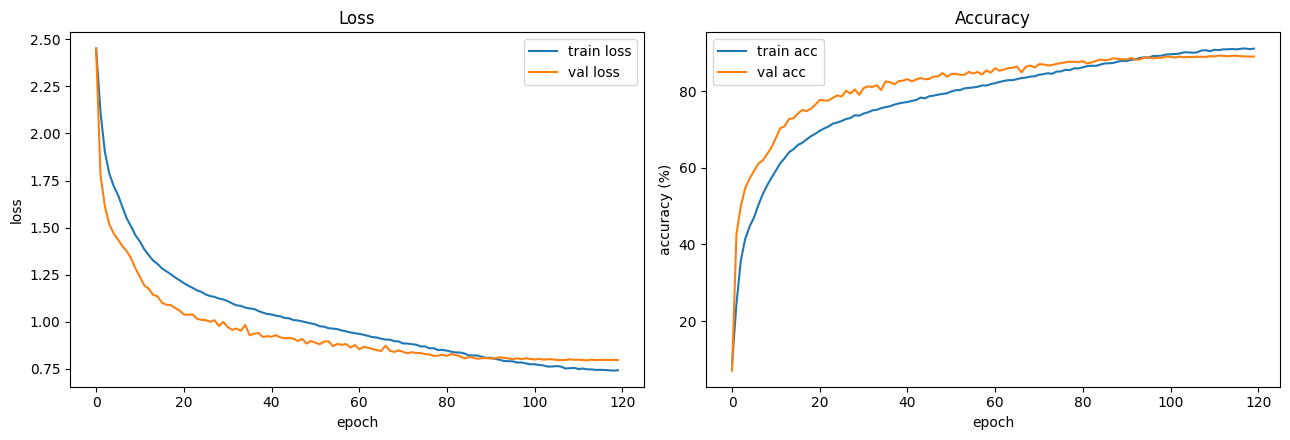

Saved curves to /kaggle/working/vit_c10_aa_ls_curves.png
Best val acc from log: 89.24%


In [17]:
# ============================================================
# Plot loss / accuracy curves from the CSV log
# ============================================================
epochs_, lrs_, tr_loss_, tr_acc_, va_loss_, va_acc_ = [], [], [], [], [], []
with open(log_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        epochs_.append(int(row["epoch"]))
        lrs_.append(float(row["lr"]))
        tr_loss_.append(float(row["train_loss"]))
        tr_acc_.append(float(row["train_acc"]))
        va_loss_.append(float(row["val_loss"]))
        va_acc_.append(float(row["val_acc"]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_, tr_loss_, label="train loss")
axes[0].plot(epochs_, va_loss_, label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs_, [a * 100 for a in tr_acc_], label="train acc")
axes[1].plot(epochs_, [a * 100 for a in va_acc_], label="val acc")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy (%)"); axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
curve_path = f"/kaggle/working/{experiment_name}_curves.png"
plt.savefig(curve_path, dpi=150)
plt.show()
print(f"Saved curves to {curve_path}")
if va_acc_:
    print(f"Best val acc from log: {max(va_acc_)*100:.2f}%")
